<a href="https://colab.research.google.com/github/Praveenraju10/15_days_workshop/blob/main/Day_3/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!pip install requests --quiet
import pandas as pd
import numpy as np
import requests

In [35]:
API_KEY='782f6a5435290bcfee5e1188c3028b87'

BASE_URL='https://api.openweathermap.org/data/2.5/weather'

CITIES=['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Puna','Jaipur']

print(f'Api configured for {len(CITIES)} cities')
print(f'cities :{CITIES}')


Api configured for 8 cities
cities :['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Puna', 'Jaipur']


In [36]:
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'], # Removed round() as it applies to a string
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')
    return None

print('Calling weather API...')
weather_record=[]

for city in CITIES:
  print(f'Fetching: {city}...',end='')
  record=fetch_weather(city,API_KEY)

  if record:
    weather_record.append(record)

    print(f'{record["temperature"]} degree celsius, {record["condition"]}') # Typo corrected: 'tempature' -> 'temperature', 'celcius' -> 'celsius'
  else:
    print('Failed')

print(f'Successfully fetched: {len(weather_record)}/{len(CITIES)}') # Typo corrected: 'successfuly' -> 'successfully', '/l' -> '/'

Calling weather API...
Fetching: Mumbai...34.0 degree celsius, Haze
Fetching: Delhi...44.0 degree celsius, Clear Sky
Fetching: Bangalore...29.8 degree celsius, Scattered Clouds
Fetching: Chennai...35.6 degree celsius, Scattered Clouds
Fetching: Hyderabad...31.2 degree celsius, Broken Clouds
Fetching: Kolkata...32.0 degree celsius, Haze
Fetching: Puna...36.3 degree celsius, Overcast Clouds
Fetching: Jaipur...42.6 degree celsius, Haze
Successfully fetched: 8/8


In [37]:
weather_df=pd.DataFrame(weather_record)
print(weather_df.to_string(index=False))
print(f'shape :{weather_df.shape}')
print(f'Missing values:{weather_df.isnull().sum().sum()}')
print(f'data types:{weather_df.dtypes}')

     city  temperature      description  humidity  wind_speed  pressure        condition  visibility
   Mumbai         34.0             haze        59        6.17      1009             Haze           7
    Delhi         44.0        clear sky        10        5.14       999        Clear Sky           7
Bangalore         29.8 scattered clouds        54        7.15      1009 Scattered Clouds           8
  Chennai         35.6 scattered clouds        55        0.89      1005 Scattered Clouds          10
Hyderabad         31.2    broken clouds        48        7.20      1010    Broken Clouds           6
  Kolkata         32.0             haze        66        3.60      1001             Haze           5
     Puna         36.3  overcast clouds        26        3.76      1008  Overcast Clouds          10
   Jaipur         42.6             haze        15        5.14      1001             Haze           5
shape :(8, 8)
Missing values:0
data types:city            object
temperature    float64
des

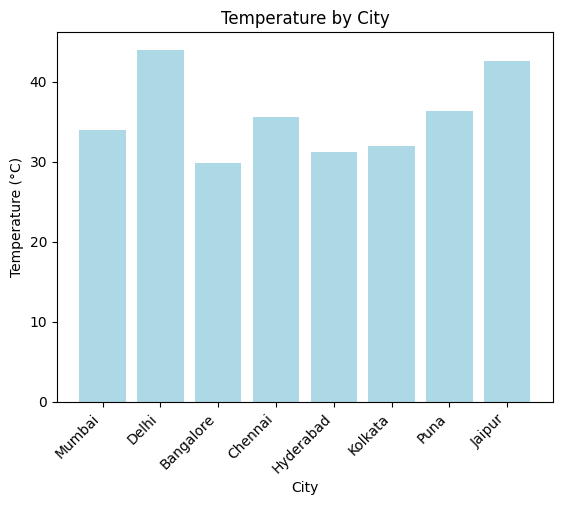

In [45]:
import matplotlib.pyplot as plt
weather_df = pd.DataFrame(weather_record)
plt.bar(weather_df['city'], weather_df['temperature'], color='lightblue')
plt.title('Temperature by City')
plt.xlabel('City')
plt.ylabel('Temperature (degree C)')
plt.xticks(rotation=45, ha='right')
plt.show()